# ResNet18

Versión final con métricas `accuracy`, `top_3`, métrica global, Optuna y matriz de probabilidades.

In [25]:
import copy
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import optuna


## Carga de datos de entrenamiento, división para obtener algunos de test y ampliación con transformaciones

En esta versión para la red convolucional se mantiene la misma idea que en el archivo fully connected:

- cargar `X_train.npz` y `Y_train.npz`
- reconstruir cada muestra a imagen de tamaño `80x70`
- dividir en train y test
- aumentar solo el conjunto de entrenamiento con transformaciones
- evaluar con `accuracy`, `top_3` y métrica global `0.7*accuracy + 0.3*top_3`
- obtener la matriz de probabilidades del test con forma `(n_test, 40)`


In [26]:
x_path = "X_train.npz"
y_path = "Y_train.npz"

def cargar_npz(ruta):
    data = np.load(ruta)

    if isinstance(data, np.lib.npyio.NpzFile):
        if len(data.files) == 0:
            raise ValueError(f"El archivo {ruta} no contiene arrays")
        array = data[data.files[0]]
    else:
        array = data

    return array

try:
    X = cargar_npz(x_path)
    Y = cargar_npz(y_path)
except FileNotFoundError:
    raise ValueError("No se encuentran X_train.npz o Y_train.npz dentro de la carpeta datasets")
except Exception as e:
    raise ValueError(f"Error al cargar los datos: {e}")

print("Shape de X:", X.shape)
print("Shape de Y:", Y.shape)

Shape de X: (240, 5600)
Shape de Y: (240,)


In [27]:
torch.manual_seed(0)

X = torch.tensor(X, dtype=torch.float32) / 255.0
Y = torch.tensor(Y, dtype=torch.long)

IMAGE_HEIGHT = 80
IMAGE_WIDTH = 70
IMAGE_SIZE = IMAGE_HEIGHT * IMAGE_WIDTH
N_CLASSES = 40

def to_image_80x70(x):
    if x.ndim == 1:
        if x.numel() != IMAGE_SIZE:
            raise ValueError(f"Se esperaban {IMAGE_SIZE} píxeles, pero llegaron {x.numel()}")
        return x.view(1, IMAGE_HEIGHT, IMAGE_WIDTH)

    if x.ndim == 2:
        if tuple(x.shape) != (IMAGE_HEIGHT, IMAGE_WIDTH):
            raise ValueError(f"Se esperaba una imagen de forma {(IMAGE_HEIGHT, IMAGE_WIDTH)}, pero llegó {tuple(x.shape)}")
        return x.unsqueeze(0)

    if x.ndim == 3:
        if tuple(x.shape) == (1, IMAGE_HEIGHT, IMAGE_WIDTH):
            return x
        raise ValueError(f"Se esperaba una imagen de forma {(1, IMAGE_HEIGHT, IMAGE_WIDTH)}, pero llegó {tuple(x.shape)}")

    raise ValueError(f"Forma de imagen no soportada: {tuple(x.shape)}")

dataset = TensorDataset(X, Y)

rotation_transform = transforms.RandomRotation((10, 10))
horizontal_flip_transform = transforms.RandomHorizontalFlip(p=1.0)

In [28]:
generator = torch.Generator().manual_seed(42)
train_dataset_base, test_dataset_base = random_split(dataset, [180, 60], generator=generator)

def augment_training_subset(subset):
    x_augmented = []
    y_augmented = []

    for x, y in subset:
        img = to_image_80x70(x)

        x_augmented.append(img.clone())
        y_augmented.append(y)

        rotated_img = rotation_transform(img)
        x_augmented.append(rotated_img)
        y_augmented.append(y)

        flipped_img = horizontal_flip_transform(img)
        x_augmented.append(flipped_img)
        y_augmented.append(y)

    return TensorDataset(torch.stack(x_augmented), torch.stack(y_augmented))

def image_subset(subset):
    x_images = []
    y_images = []

    for x, y in subset:
        img = to_image_80x70(x)
        x_images.append(img)
        y_images.append(y)

    return TensorDataset(torch.stack(x_images), torch.stack(y_images))

train_dataset = augment_training_subset(train_dataset_base)
test_dataset = image_subset(test_dataset_base)

N_training = len(train_dataset)
N_test = len(test_dataset)

print("Total original:", len(dataset))
print("Train original:", len(train_dataset_base))
print("Train con augmentación:", len(train_dataset))
print("Test:", len(test_dataset))
print("Forma de una imagen de train:", train_dataset[0][0].shape)

Total original: 240
Train original: 180
Train con augmentación: 540
Test: 60
Forma de una imagen de train: torch.Size([1, 80, 70])


## Visualización de algunas imágenes tras las transformaciones

Ejecuta esta celda para comparar imágenes del conjunto de entrenamiento reconstruidas a `80x70`
con sus versiones rotadas y espejadas.


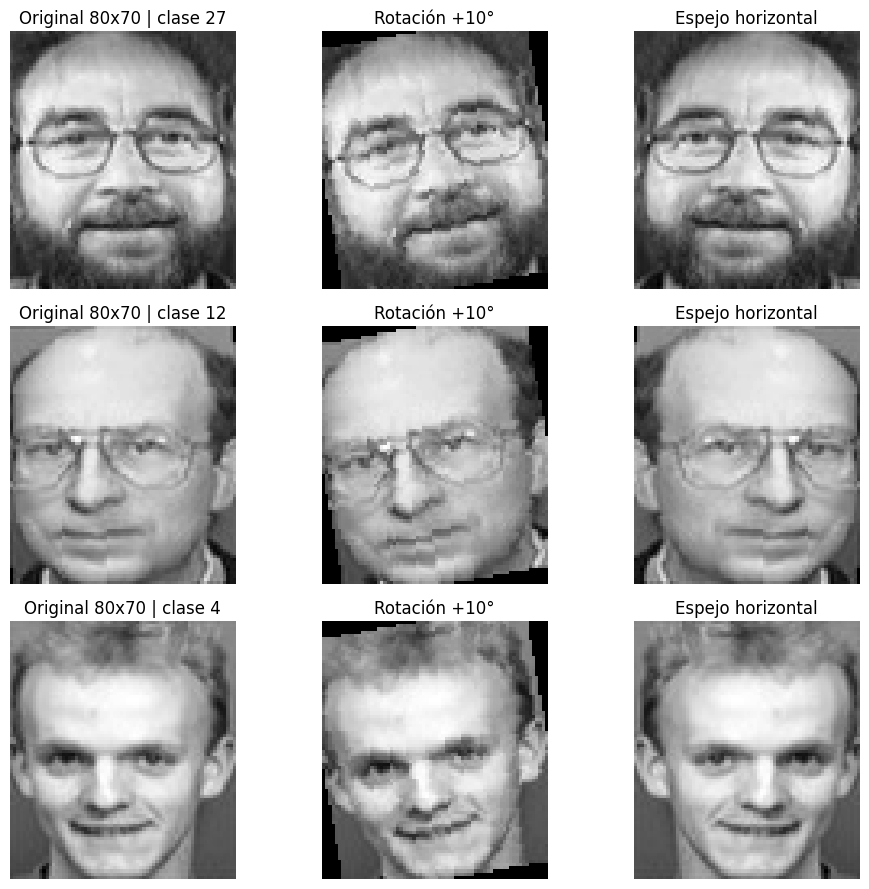

In [29]:
num_examples = 3
indices = torch.randperm(len(train_dataset_base))[:num_examples]

fig, axes = plt.subplots(num_examples, 3, figsize=(10, 3 * num_examples))

if num_examples == 1:
    axes = np.expand_dims(axes, axis=0)

for row, idx in enumerate(indices):
    x, y = train_dataset_base[idx]
    img = to_image_80x70(x)

    original_img = img.squeeze(0).cpu().numpy()
    rotated_img = rotation_transform(img).squeeze(0).cpu().numpy()
    flipped_img = horizontal_flip_transform(img).squeeze(0).cpu().numpy()

    images = [original_img, rotated_img, flipped_img]
    titles = [f"Original 80x70 | clase {int(y)}", "Rotación +10°", "Espejo horizontal"]

    for col, (image, title) in enumerate(zip(images, titles)):
        axes[row, col].imshow(image, cmap="gray")
        axes[row, col].set_title(title)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

## Definimos la arquitectura ResNet18 adaptada al problema

In [30]:
class ResNet18(nn.Module):
    def __init__(
        self,
        dim_out,
        activation,
        apply_bn,
        drop_prob,
        link_function,
        loss_function
    ):
        super(ResNet18, self).__init__()

        self.activation = activation
        self.apply_bn = apply_bn
        self.drop = nn.Dropout2d(drop_prob)
        self.link = link_function
        self.loss = loss_function

        # Adaptada a imágenes en escala de grises [1, 80, 70]
        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)

        # Block 1
        self.b1_conv1 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.b1_bn1 = nn.BatchNorm2d(64)
        self.b1_conv2 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.b1_bn2 = nn.BatchNorm2d(64)

        # Block 2
        self.b2_conv1 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.b2_bn1 = nn.BatchNorm2d(64)
        self.b2_conv2 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.b2_bn2 = nn.BatchNorm2d(64)

        # Block 3
        self.b3_conv1 = nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1, bias=False)
        self.b3_bn1 = nn.BatchNorm2d(128)
        self.b3_conv2 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1, bias=False)
        self.b3_bn2 = nn.BatchNorm2d(128)
        self.b3_shortcut_conv = nn.Conv2d(64, 128, kernel_size=1, stride=2, bias=False)
        self.b3_shortcut_bn = nn.BatchNorm2d(128)

        # Block 4
        self.b4_conv1 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1, bias=False)
        self.b4_bn1 = nn.BatchNorm2d(128)
        self.b4_conv2 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1, bias=False)
        self.b4_bn2 = nn.BatchNorm2d(128)

        # Block 5
        self.b5_conv1 = nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1, bias=False)
        self.b5_bn1 = nn.BatchNorm2d(256)
        self.b5_conv2 = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=False)
        self.b5_bn2 = nn.BatchNorm2d(256)
        self.b5_shortcut_conv = nn.Conv2d(128, 256, kernel_size=1, stride=2, bias=False)
        self.b5_shortcut_bn = nn.BatchNorm2d(256)

        # Block 6
        self.b6_conv1 = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=False)
        self.b6_bn1 = nn.BatchNorm2d(256)
        self.b6_conv2 = nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1, bias=False)
        self.b6_bn2 = nn.BatchNorm2d(256)

        # Block 7
        self.b7_conv1 = nn.Conv2d(256, 512, kernel_size=3, stride=2, padding=1, bias=False)
        self.b7_bn1 = nn.BatchNorm2d(512)
        self.b7_conv2 = nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1, bias=False)
        self.b7_bn2 = nn.BatchNorm2d(512)
        self.b7_shortcut_conv = nn.Conv2d(256, 512, kernel_size=1, stride=2, bias=False)
        self.b7_shortcut_bn = nn.BatchNorm2d(512)

        # Block 8
        self.b8_conv1 = nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1, bias=False)
        self.b8_bn1 = nn.BatchNorm2d(512)
        self.b8_conv2 = nn.Conv2d(512, 512, kernel_size=3, stride=1, padding=1, bias=False)
        self.b8_bn2 = nn.BatchNorm2d(512)

        # Pooling adaptativo para imágenes 80x70
        self.average_pooling = nn.AdaptiveAvgPool2d((1, 1))
        self.Linear = nn.Linear(512, dim_out)

    def operator(self, x):
        x = self.conv1(x)
        if self.apply_bn:
            x = self.bn1(x)
        x = self.drop(self.activation(x))

        x_block = self.b1_conv1(x)
        if self.apply_bn:
            x_block = self.b1_bn1(x_block)
        x_block = self.b1_conv2(self.drop(self.activation(x_block)))
        if self.apply_bn:
            x_block = self.b1_bn2(x_block)
        x = self.drop(self.activation(x + x_block))

        x_block = self.b2_conv1(x)
        if self.apply_bn:
            x_block = self.b2_bn1(x_block)
        x_block = self.b2_conv2(self.drop(self.activation(x_block)))
        if self.apply_bn:
            x_block = self.b2_bn2(x_block)
        x = self.drop(self.activation(x + x_block))

        x_block = self.b3_conv1(x)
        if self.apply_bn:
            x_block = self.b3_bn1(x_block)
        x_block = self.b3_conv2(self.drop(self.activation(x_block)))
        if self.apply_bn:
            x_block = self.b3_bn2(x_block)
        input_readapted = self.b3_shortcut_conv(x)
        if self.apply_bn:
            input_readapted = self.b3_shortcut_bn(input_readapted)
        x = self.drop(self.activation(input_readapted + x_block))

        x_block = self.b4_conv1(x)
        if self.apply_bn:
            x_block = self.b4_bn1(x_block)
        x_block = self.b4_conv2(self.drop(self.activation(x_block)))
        if self.apply_bn:
            x_block = self.b4_bn2(x_block)
        x = self.drop(self.activation(x + x_block))

        x_block = self.b5_conv1(x)
        if self.apply_bn:
            x_block = self.b5_bn1(x_block)
        x_block = self.b5_conv2(self.drop(self.activation(x_block)))
        if self.apply_bn:
            x_block = self.b5_bn2(x_block)
        input_readapted = self.b5_shortcut_conv(x)
        if self.apply_bn:
            input_readapted = self.b5_shortcut_bn(input_readapted)
        x = self.drop(self.activation(input_readapted + x_block))

        x_block = self.b6_conv1(x)
        if self.apply_bn:
            x_block = self.b6_bn1(x_block)
        x_block = self.b6_conv2(self.drop(self.activation(x_block)))
        if self.apply_bn:
            x_block = self.b6_bn2(x_block)
        x = self.drop(self.activation(x + x_block))

        x_block = self.b7_conv1(x)
        if self.apply_bn:
            x_block = self.b7_bn1(x_block)
        x_block = self.b7_conv2(self.drop(self.activation(x_block)))
        if self.apply_bn:
            x_block = self.b7_bn2(x_block)
        input_readapted = self.b7_shortcut_conv(x)
        if self.apply_bn:
            input_readapted = self.b7_shortcut_bn(input_readapted)
        x = self.drop(self.activation(input_readapted + x_block))

        x_block = self.b8_conv1(x)
        if self.apply_bn:
            x_block = self.b8_bn1(x_block)
        x_block = self.b8_conv2(self.drop(self.activation(x_block)))
        if self.apply_bn:
            x_block = self.b8_bn2(x_block)
        x = self.drop(self.activation(x + x_block))

        x = self.average_pooling(x)
        x = self.Linear(x.view(x.size(0), -1))
        return x

    def forward_train(self, x, apply_link):
        self.train()
        x = self.operator(x)
        if apply_link:
            x = self.link(x)
        return x

    def forward_eval(self, x, apply_link):
        self.eval()
        x = self.operator(x)
        if apply_link:
            x = self.link(x)
        return x

    def compute_loss(self, t, y):
        return self.loss(y, t)

## Métricas de evaluación

In [31]:
def compute_metric(dataloader, model):
    acc = 0
    tot_samples = 0

    model.eval()
    with torch.no_grad():
        for x, t in dataloader:
            x, t = x.to(device), t.to(device)
            y = model.forward_eval(x, apply_link=False)

            acc += (t == torch.argmax(y, dim=1)).sum().item()
            tot_samples += len(t)

    return acc / tot_samples


def compute_metric_top3(dataloader, model, k=3):
    acc = compute_metric(dataloader, model)

    top_k_acc = 0
    tot_samples = 0

    model.eval()
    with torch.no_grad():
        for x, t in dataloader:
            x, t = x.to(device), t.to(device)
            y = model.forward_eval(x, apply_link=False)

            top_k_preds = torch.topk(y, k=k, dim=1).indices
            top_k_acc += top_k_preds.eq(t.view(-1, 1)).any(dim=1).sum().item()
            tot_samples += len(t)

    top_k_acc = top_k_acc / tot_samples
    global_metric = 0.7 * acc + 0.3 * top_k_acc

    return acc, top_k_acc, global_metric

## Función de entrenamiento y evaluación

In [32]:
def test_model(
    model: torch.nn.Module,
    epochs: int,
    train_batch_size: int,
    lr: float,
    betas: tuple,
    eps: float,
    mode: str,
    weight_decay: float,
    factor: float,
    patience: int,
    min_lr: float,
    mmu: float,
    apply_scheduler: bool,
    eval_each: int,
    train_dataset: torchvision.datasets,
    test_dataset: torchvision.datasets
):
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)
    train_loader_eval = torch.utils.data.DataLoader(train_dataset, batch_size=train_batch_size, shuffle=False)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=train_batch_size, shuffle=False)

    N_training = len(train_dataset)

    loss_epochs = []
    train_acc_epochs = []
    test_acc_epochs = []
    train_top3_epochs = []
    test_top3_epochs = []
    train_global_epochs = []
    test_global_epochs = []

    with torch.no_grad():
        loss_acc = 0.0
        for batch_idx, (x, t) in enumerate(train_loader_eval):
            x, t = x.to(device), t.to(device)

            y = model.forward_train(x, apply_link=False)
            L = model.compute_loss(t, y)
            loss_acc += len(x) * L.item()

        train_acc, train_top3, train_global = compute_metric_top3(train_loader_eval, model, k=3)
        test_acc, test_top3, test_global = compute_metric_top3(test_loader, model, k=3)

    loss_epochs.append(loss_acc / N_training)
    train_acc_epochs.append(train_acc)
    test_acc_epochs.append(test_acc)
    train_top3_epochs.append(train_top3)
    test_top3_epochs.append(test_top3)
    train_global_epochs.append(train_global)
    test_global_epochs.append(test_global)

    best_metric = test_global
    best_epoch = 0
    best_state_dict = copy.deepcopy(model.state_dict())

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        betas=betas,
        eps=eps,
        weight_decay=weight_decay
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode=mode,
        factor=factor,
        patience=patience,
        min_lr=min_lr
    )

    for e in range(epochs):
        model.train()
        loss_acc = 0.0

        for batch_idx, (x, t) in enumerate(train_loader):
            x, t = x.to(device), t.to(device)

            y = model.forward_train(x, apply_link=False)
            L = model.compute_loss(t, y)
            loss_acc += len(x) * L.item()

            L.backward()
            optimizer.step()
            optimizer.zero_grad()

            print(f"On epoch {e+1} batch_idx {batch_idx + 1} got loss {L.item():.5f}", end="\r")

        if (e + 1) % eval_each == 0 or e == 0:
            with torch.no_grad():
                train_acc, train_top3, train_global = compute_metric_top3(train_loader_eval, model, k=3)
                test_acc, test_top3, test_global = compute_metric_top3(test_loader, model, k=3)

            if apply_scheduler:
                scheduler.step(test_global)

            if test_global > best_metric:
                best_metric = test_global
                best_epoch = e + 1
                best_state_dict = copy.deepcopy(model.state_dict())

            print(" " * 300, end="\r")
            print(
                f"On epoch {e+1} got loss {loss_acc/N_training:.5f} "
                f"with train accuracy {train_acc:.5f}, train top3 {train_top3:.5f}, train global {train_global:.5f} "
                f"and test accuracy {test_acc:.5f}, test top3 {test_top3:.5f}, test global {test_global:.5f}"
            )
        else:
            print(" " * 300, end="\r")
            print(f"On epoch {e+1} got loss {loss_acc/N_training:.5f}")

        loss_epochs.append(loss_acc / N_training)
        train_acc_epochs.append(train_acc)
        test_acc_epochs.append(test_acc)
        train_top3_epochs.append(train_top3)
        test_top3_epochs.append(test_top3)
        train_global_epochs.append(train_global)
        test_global_epochs.append(test_global)

    model.load_state_dict(best_state_dict)

    if best_epoch == 0:
        print(f"Se ha restaurado el mejor modelo inicial (antes de entrenar) con test_global = {best_metric:.5f}")
    else:
        print(f"Se ha restaurado el mejor modelo de la época {best_epoch} con test_global = {best_metric:.5f}")

    return (
        loss_epochs,
        train_acc_epochs,
        test_acc_epochs,
        train_top3_epochs,
        test_top3_epochs,
        train_global_epochs,
        test_global_epochs
    )

## Optuna

Búsqueda de hiperparámetros con la misma lógica general que en el notebook fully connected.

In [33]:

def objective(trial):
    torch.manual_seed(0)

    drop_prob = trial.suggest_categorical("drop_prob", [0.05, 0.10, 0.15, 0.20])

    apply_bn = trial.suggest_categorical("apply_bn", [True])

    lr = trial.suggest_float("lr", 5e-4, 1.5e-3, log=True)
    beta1 = trial.suggest_float("beta1", 0.84, 0.89)
    beta2 = trial.suggest_float("beta2", 0.995, 0.9995)

    eps = trial.suggest_float("eps", 1e-9, 1e-7, log=True)

    weight_decay = trial.suggest_float("weight_decay", 8e-4, 3e-3, log=True)

    train_batch_size = trial.suggest_categorical("train_batch_size", [32, 64])

    factor = trial.suggest_categorical("factor", [0.25, 0.30, 0.40])
    patience = trial.suggest_int("patience", 12, 18)
    min_lr = trial.suggest_float("min_lr", 1e-5, 4e-5, log=True)

    model = ResNet18(
        dim_out=N_CLASSES,
        activation=torch.relu,
        apply_bn=apply_bn,
        drop_prob=drop_prob,
        link_function=lambda x: torch.softmax(x, dim=1),
        loss_function=nn.CrossEntropyLoss(),
    )
    model.to(device)

    (
        loss,
        train_acc,
        test_acc,
        train_top3,
        test_top3,
        train_global,
        test_global
    ) = test_model(
        model,
        epochs=100,
        lr=lr,
        betas=(beta1, beta2),
        eps=eps,
        weight_decay=weight_decay,
        mmu=0.8,
        train_batch_size=train_batch_size,
        apply_scheduler=True,
        mode='max',
        factor=factor,
        patience=patience,
        min_lr=min_lr,
        eval_each=1,
        train_dataset=train_dataset,
        test_dataset=test_dataset
    )

    best_epoch = int(np.argmax(test_global))
    best_test_global = float(test_global[best_epoch])

    trial.set_user_attr("best_epoch", best_epoch)
    trial.set_user_attr("best_test_acc", float(test_acc[best_epoch]))
    trial.set_user_attr("best_test_top3", float(test_top3[best_epoch]))

    return best_test_global


In [34]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=0)
)

study.optimize(objective, n_trials=3)

print("Mejor métrica global:", study.best_value)
print("Mejores hiperparámetros:", study.best_params)
print("Mejor época:", study.best_trial.user_attrs["best_epoch"])
print("Accuracy en esa época:", study.best_trial.user_attrs["best_test_acc"])
print("Top-3 en esa época:", study.best_trial.user_attrs["best_test_top3"])


[I 2026-04-20 20:21:23,613] A new study created in memory with name: no-name-7e20a608-f777-4928-8a94-fec8d7938d22


cuda
On epoch 1 got loss 3.67787 with train accuracy 0.05556, train top3 0.12222, train global 0.07556 and test accuracy 0.03333, test top3 0.05000, test global 0.03833                                                                                                                                         
On epoch 2 got loss 3.06561 with train accuracy 0.14444, train top3 0.25926, train global 0.17889 and test accuracy 0.10000, test top3 0.21667, test global 0.13500                                                                                                                                         
On epoch 3 got loss 2.66395 with train accuracy 0.08704, train top3 0.17407, train global 0.11315 and test accuracy 0.03333, test top3 0.18333, test global 0.07833                                                                                                                                         
On epoch 4 got loss 2.33263 with train accuracy 0.11852, train top3 0.29074, train global 0.

[I 2026-04-20 20:25:00,645] Trial 0 finished with value: 0.8983333333333332 and parameters: {'drop_prob': 0.1, 'apply_bn': True, 'lr': 0.0007963513374162744, 'beta1': 0.8722947056533328, 'beta2': 0.9969691424506821, 'eps': 6.074996073425689e-08, 'weight_decay': 0.0028593185584096553, 'train_batch_size': 64, 'factor': 0.4, 'patience': 12, 'min_lr': 1.12838437934969e-05}. Best is trial 0 with value: 0.8983333333333332.


On epoch 100 got loss 0.00877 with train accuracy 1.00000, train top3 1.00000, train global 1.00000 and test accuracy 0.86667, test top3 0.91667, test global 0.88167                                                                                                                                       
Se ha restaurado el mejor modelo de la época 82 con test_global = 0.89833
On epoch 1 got loss 3.93276 with train accuracy 0.05926, train top3 0.12407, train global 0.07870 and test accuracy 0.05000, test top3 0.11667, test global 0.07000                                                                                                                                         
On epoch 2 got loss 3.55153 with train accuracy 0.06481, train top3 0.19630, train global 0.10426 and test accuracy 0.06667, test top3 0.20000, test global 0.10667                                                                                                                                         
On epoch 3 got loss 3.2

[I 2026-04-20 20:28:24,720] Trial 1 finished with value: 0.8816666666666666 and parameters: {'drop_prob': 0.2, 'apply_bn': True, 'lr': 0.0014651753910158317, 'beta1': 0.8799579282108362, 'beta2': 0.9970766571301383, 'eps': 3.639639356786381e-08, 'weight_decay': 0.0009353695022375585, 'train_batch_size': 32, 'factor': 0.25, 'patience': 13, 'min_lr': 2.9250623533806567e-05}. Best is trial 0 with value: 0.8983333333333332.


On epoch 100 got loss 0.01389 with train accuracy 1.00000, train top3 1.00000, train global 1.00000 and test accuracy 0.86667, test top3 0.88333, test global 0.87167                                                                                                                                       
Se ha restaurado el mejor modelo de la época 59 con test_global = 0.88167
On epoch 1 got loss 3.84277 with train accuracy 0.04444, train top3 0.10185, train global 0.06167 and test accuracy 0.01667, test top3 0.06667, test global 0.03167                                                                                                                                         
On epoch 2 got loss 3.54290 with train accuracy 0.12037, train top3 0.26296, train global 0.16315 and test accuracy 0.11667, test top3 0.21667, test global 0.14667                                                                                                                                         
On epoch 3 got loss 3.1

[I 2026-04-20 20:32:01,365] Trial 2 finished with value: 0.855 and parameters: {'drop_prob': 0.2, 'apply_bn': True, 'lr': 0.000979521298344026, 'beta1': 0.8708466998437379, 'beta2': 0.9992468663533158, 'eps': 2.3101522250182352e-08, 'weight_decay': 0.0012866450778424975, 'train_batch_size': 64, 'factor': 0.4, 'patience': 13, 'min_lr': 1.1956976223476421e-05}. Best is trial 0 with value: 0.8983333333333332.


On epoch 100 got loss 0.03895 with train accuracy 1.00000, train top3 1.00000, train global 1.00000 and test accuracy 0.83333, test top3 0.86667, test global 0.84333                                                                                                                                       
Se ha restaurado el mejor modelo de la época 95 con test_global = 0.85500
Mejor métrica global: 0.8983333333333332
Mejores hiperparámetros: {'drop_prob': 0.1, 'apply_bn': True, 'lr': 0.0007963513374162744, 'beta1': 0.8722947056533328, 'beta2': 0.9969691424506821, 'eps': 6.074996073425689e-08, 'weight_decay': 0.0028593185584096553, 'train_batch_size': 64, 'factor': 0.4, 'patience': 12, 'min_lr': 1.12838437934969e-05}
Mejor época: 82
Accuracy en esa época: 0.8833333333333333
Top-3 en esa época: 0.9333333333333333


## Reentrenamiento final con los mejores hiperparámetros


In [38]:

best = study.best_params

torch.manual_seed(0)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Usando:", device)
print("Hiperparámetros óptimos:", best)

model = ResNet18(
    dim_out=N_CLASSES,
    activation=torch.relu,
    apply_bn=best["apply_bn"],
    drop_prob=best["drop_prob"],
    link_function=lambda x: torch.softmax(x, dim=1),
    loss_function=nn.CrossEntropyLoss(),
)
model.to(device)

(
    resnet18_loss,
    resnet18_train_acc,
    resnet18_test_acc,
    resnet18_train_top3,
    resnet18_test_top3,
    resnet18_train_global,
    resnet18_test_global
) = test_model(
    model,
    epochs=200,
    lr=best["lr"],
    betas=(best["beta1"], best["beta2"]),
    eps=best["eps"],
    weight_decay=best["weight_decay"],
    mmu=0.8,
    train_batch_size=best["train_batch_size"],
    apply_scheduler=True,
    mode='max',
    factor=best["factor"],
    patience=best["patience"],
    min_lr=best["min_lr"],
    eval_each=1,
    train_dataset=train_dataset,
    test_dataset=test_dataset
)


Usando: cuda
Hiperparámetros óptimos: {'drop_prob': 0.1, 'apply_bn': True, 'lr': 0.0007963513374162744, 'beta1': 0.8722947056533328, 'beta2': 0.9969691424506821, 'eps': 6.074996073425689e-08, 'weight_decay': 0.0028593185584096553, 'train_batch_size': 64, 'factor': 0.4, 'patience': 12, 'min_lr': 1.12838437934969e-05}
On epoch 1 got loss 3.67787 with train accuracy 0.05556, train top3 0.12222, train global 0.07556 and test accuracy 0.03333, test top3 0.05000, test global 0.03833                                                                                                                                         
On epoch 2 got loss 3.06561 with train accuracy 0.14444, train top3 0.25926, train global 0.17889 and test accuracy 0.10000, test top3 0.21667, test global 0.13500                                                                                                                                         
On epoch 3 got loss 2.66395 with train accuracy 0.08704, train top3 0.17407, tra

## Resumen del mejor resultado


In [ ]:

best_epoch = np.argmax(resnet18_test_global)
best_test_acc = resnet18_test_acc[best_epoch]
best_train_acc = resnet18_train_acc[best_epoch]
best_loss = resnet18_loss[best_epoch]

print(f"Mejor época: {best_epoch}")
print(f"Mejor test accuracy: {best_test_acc:.4f}")
print(f"Mejor test top3: {resnet18_test_top3[best_epoch]:.4f}")
print(f"Mejor test global: {resnet18_test_global[best_epoch]:.4f}")
print(f"Train accuracy en esa época: {best_train_acc:.4f}")
print(f"Train top3 en esa época: {resnet18_train_top3[best_epoch]:.4f}")
print(f"Train global en esa época: {resnet18_train_global[best_epoch]:.4f}")
print(f"Loss en esa época: {best_loss:.4f}")


Mejor época: 18
Mejor test accuracy: 0.8333
Mejor test top3: 0.9000
Mejor test global: 0.8533
Train accuracy en esa época: 0.9981
Train top3 en esa época: 1.0000
Train global en esa época: 0.9987
Loss en esa época: 0.3051


## Gráficas de evolución


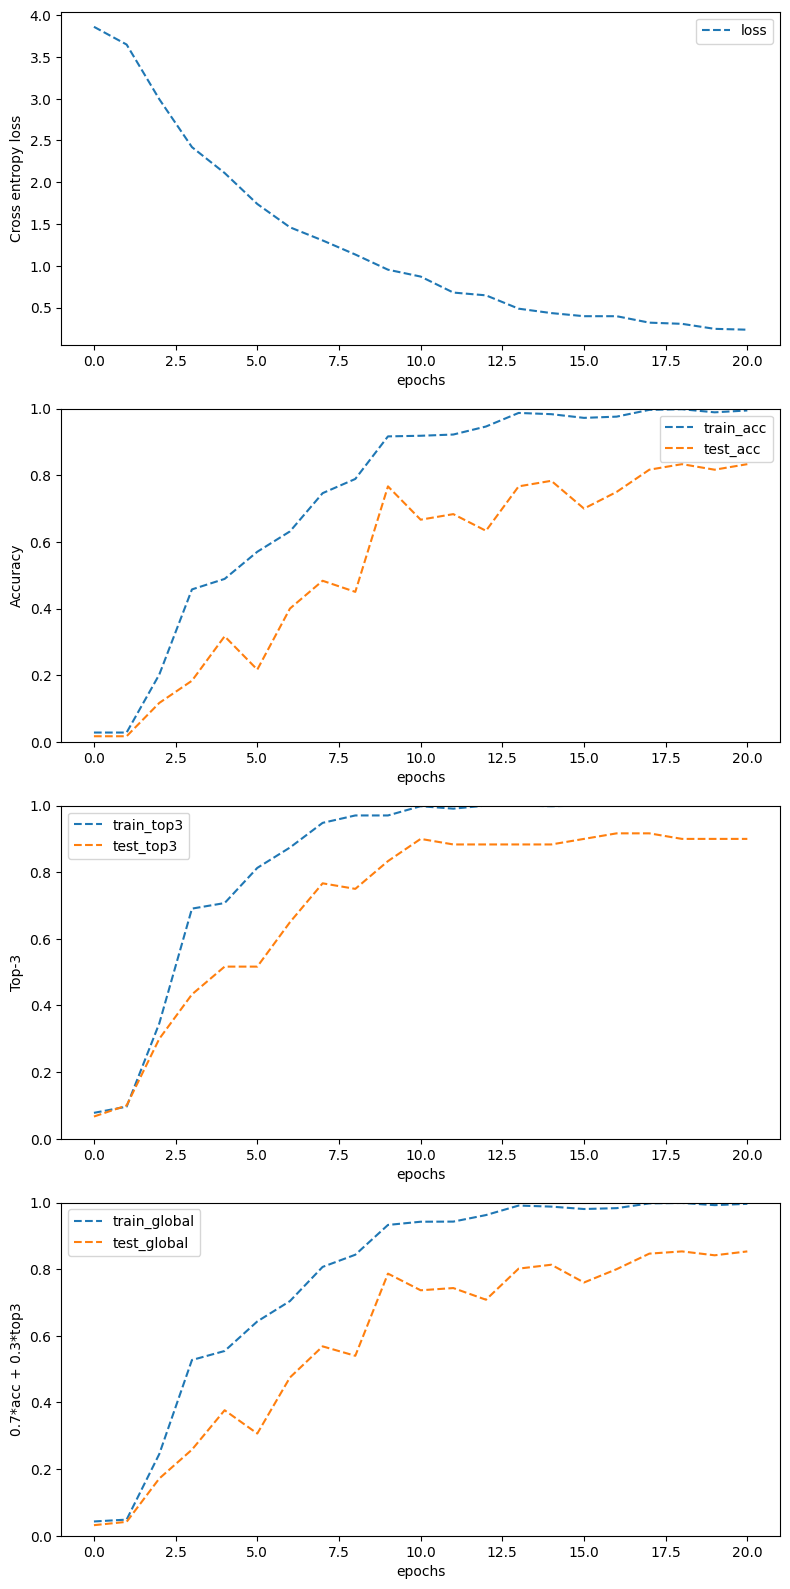

In [ ]:

fig, (ax11, ax21, ax31, ax41) = plt.subplots(4, 1, figsize=(8, 16))

ax11.plot(range(len(resnet18_loss)), resnet18_loss, linestyle='--')
ax11.set_ylabel('Cross entropy loss')
ax11.set_xlabel('epochs')
ax11.legend(['loss'])

ax21.plot(range(len(resnet18_train_acc)), resnet18_train_acc, linestyle='--')
ax21.plot(range(len(resnet18_test_acc)), resnet18_test_acc, linestyle='--')
ax21.set_ylim([0.0, 1.0])
ax21.set_ylabel('Accuracy')
ax21.set_xlabel('epochs')
ax21.legend(['train_acc', 'test_acc'])

ax31.plot(range(len(resnet18_train_top3)), resnet18_train_top3, linestyle='--')
ax31.plot(range(len(resnet18_test_top3)), resnet18_test_top3, linestyle='--')
ax31.set_ylim([0.0, 1.0])
ax31.set_ylabel('Top-3')
ax31.set_xlabel('epochs')
ax31.legend(['train_top3', 'test_top3'])

ax41.plot(range(len(resnet18_train_global)), resnet18_train_global, linestyle='--')
ax41.plot(range(len(resnet18_test_global)), resnet18_test_global, linestyle='--')
ax41.set_ylim([0.0, 1.0])
ax41.set_ylabel('0.7*acc + 0.3*top3')
ax41.set_xlabel('epochs')
ax41.legend(['train_global', 'test_global'])

plt.tight_layout()
plt.show()


## Matriz de probabilidades sobre el conjunto de test


In [ ]:

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

n_test = len(test_dataset)
n_clases = N_CLASSES

matriz_probs = torch.zeros((n_test, n_clases))

model.eval()

indice = 0
with torch.no_grad():
    for x, _ in test_loader:
        x = x.to(device)

        logits = model.forward_eval(x, apply_link=False)
        probs = torch.softmax(logits, dim=1).cpu()

        batch_size = probs.shape[0]
        matriz_probs[indice:indice + batch_size, :] = probs
        indice += batch_size

assert matriz_probs.shape[0] == len(test_dataset)
assert matriz_probs.shape[1] == N_CLASSES

torch.set_printoptions(precision=6, linewidth=220, threshold=1000000)
print("Shape matriz_probs:", matriz_probs.shape)
print(matriz_probs)


Shape matriz_probs: torch.Size([60, 40])
tensor([[5.100359e-09, 1.297725e-04, 5.313916e-06, 2.485071e-06, 1.061675e-04, 2.138510e-05, 4.414055e-06, 2.073606e-08, 1.433260e-05, 4.492935e-10, 1.322528e-06, 1.505978e-07, 2.847036e-05, 9.636057e-07, 1.914105e-03,
         7.178080e-08, 1.062139e-06, 1.548509e-07, 4.856571e-06, 3.715798e-06, 2.393699e-04, 1.449054e-03, 4.470565e-06, 4.597921e-06, 1.232313e-04, 2.593189e-06, 4.204153e-07, 2.229831e-09, 3.872827e-06, 3.563093e-04,
         9.942765e-01, 2.629563e-06, 1.574758e-04, 7.891795e-04, 3.919685e-05, 3.931811e-05, 1.914006e-06, 9.474549e-07, 2.567198e-04, 1.339498e-05],
        [1.898721e-08, 2.049546e-03, 9.755671e-06, 6.127586e-06, 2.101769e-04, 1.089137e-05, 3.045506e-06, 1.238560e-08, 1.820124e-05, 4.302382e-10, 7.374997e-07, 2.555302e-07, 1.512223e-04, 1.446530e-06, 4.536067e-03,
         6.075261e-07, 3.598644e-06, 6.071623e-07, 8.089336e-05, 1.279254e-05, 1.525918e-04, 1.395259e-04, 2.052986e-06, 1.324645e-05, 3.966065e-04, 9.6

In [ ]:

matriz_probs_np = matriz_probs.numpy()
print("Shape matriz_probs_np:", matriz_probs_np.shape)
print(matriz_probs_np)


Shape matriz_probs_np: (60, 40)
[[5.10035925e-09 1.29772481e-04 5.31391606e-06 ... 9.47454851e-07
  2.56719766e-04 1.33949816e-05]
 [1.89872100e-08 2.04954552e-03 9.75567127e-06 ... 5.95778317e-07
  2.85007754e-05 1.70318708e-05]
 [1.04925002e-05 3.37819765e-05 9.18601145e-05 ... 1.55913427e-01
  7.52213830e-03 2.70811524e-05]
 ...
 [1.90612286e-06 4.41505745e-06 1.02362287e-06 ... 6.18680569e-05
  8.23542905e-06 7.35944705e-05]
 [1.07983993e-04 1.22355239e-04 7.52511260e-04 ... 3.74120264e-03
  1.80328370e-03 1.39030773e-04]
 [1.19470367e-02 2.35300744e-03 1.19046046e-04 ... 8.06638927e-05
  2.39652902e-04 6.77430304e-03]]
